In [ ]:
%pip install qiskit matplotlib qiskit[visualization]

In [ ]:
%pip install qiskit-ibm-runtime

In [ ]:
%pip install qiskit-aer

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.measure_all()

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
print(result[0].data.meas.get_counts())

{'11': 507, '00': 517}


In [8]:
import os
QISKIT_APIKEY = os.getenv("QISKIT_APIKEY")
print(QISKIT_APIKEY)

pjQIiifWy8a_GmVE3wmJe8dKruDcIuMjh8Z82PSAjPns


In [9]:
# 양자컴퓨팅 서비스에 연결
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    token=QISKIT_APIKEY,
    channel="ibm_quantum_platform"
)
backend = service.least_busy(
    operational=True, simulator=False
)
print(backend.name)

qiskit_runtime_service._discover_account:WARNING:2026-03-30 17:12:37,778: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-03-30 17:12:42,935: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-30 17:12:43,654: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-30 17:12:47,715: Using instance: open-instance, plan: open


ibm_fez


In [ ]:
# 실제 양자컴퓨터 실행 코드 (크레딧 사용)
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.measure_all()

sampler = Sampler(backend)
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
# job = sampler.run([isa_circuit], shots=1024)
# print(f"job id: {job.job_id()}")

# result = job.result()
# print(result[0].data.meas.get_counts())


job id: d74shph8qmgc73fmf63g
{'11': 461, '00': 504, '01': 29, '10': 30}


In [ ]:
# 시뮬레이터 사용 소스코드 예제 (무료, 무한정)
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.measure_all()

backend = AerSimulator()
job = backend.run(qc, shots=1024)
result = job.result()   

counts = result.get_counts()
print("AER counts:", counts)

AER counts: {'00': 515, '11': 509}


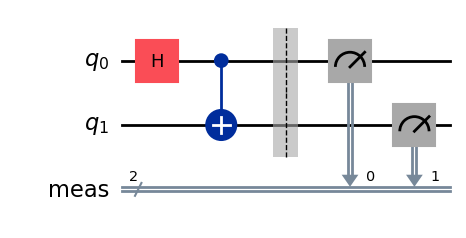

In [6]:
# 양자회로 출력
qc.draw(output="mpl")


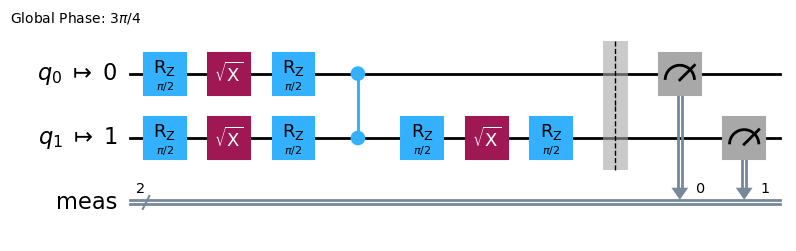

In [7]:
isa_circuit.draw(output="mpl", filename="isa_circuit.png")